<a href="https://colab.research.google.com/github/h186487/DAT158MLSopp/blob/main/notebooks/02_modeling_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone
Henter først repoet inn i Colab-sesjonen.
Går så inn i mappen og henter siste endringer.

In [1]:
import os
if os.path.basename(os.getcwd()) != "DAT158MLSopp":
  if not os.path.exists("DAT158MLSopp"):
    !git clone https://github.com/h186487/DAT158MLSopp.git
  %cd DAT158MLSopp
!git pull
!pip install -q ucimlrepo

Cloning into 'DAT158MLSopp'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 109 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 1.77 MiB | 4.01 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/DAT158MLSopp
Already up to date.


Felles hjelpefunksjoner:

In [2]:
%%writefile src/modeling_utils.py
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, accuracy_score, confusion_matrix

SEED = 42

def make_pipeline(model, columns):
    """Pipeline: one-hot-koding av de oppgitte kolonnene + modell."""
    pre = ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), list(columns))]
    )
    return Pipeline([("pre", pre), ("model", model)])


def mask_unknown(X, p, seed=SEED):
    """Erstatter hver verdi med 'unknown' med sannsynlighet p ('Vet ikke')."""
    rng = np.random.default_rng(seed)
    return X.mask(rng.random(X.shape) < p, "unknown")


def corrupt(X, p, seed=SEED):
    """Erstatter hver verdi med en TILFELDIG ANNEN verdi fra samme kolonne
    med sannsynlighet p (brukeren svarer feil)."""
    rng = np.random.default_rng(seed)
    Xn = X.copy()
    for col in X.columns:
        values = X[col].unique()
        hit = rng.random(len(X)) < p
        Xn.loc[hit, col] = rng.choice(values, hit.sum())
    return Xn


def augment(X, y, ps=(0.2, 0.4), seed=SEED):
    """Originale data + maskerte kopier. KUN for treningsdata."""
    Xs, ys = [X], [y]
    for i, p in enumerate(ps):
        Xs.append(mask_unknown(X, p, seed + i + 1))
        ys.append(y)
    return pd.concat(Xs, ignore_index=True), pd.concat(ys, ignore_index=True)


def cv_evaluate(make_model, X, y, n_splits=5, n_repeats=1,
                augment_train=False, seed=SEED):
    """Stratifisert (repetert) CV. Returnerer én rad per fold.
    Augmentering skjer INNE i hver fold, kun på treningsdelen."""
    rows = []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for tr, va in skf.split(X, y):
            Xtr, ytr = X.iloc[tr], y.iloc[tr]
            Xva, yva = X.iloc[va], y.iloc[va]
            if augment_train:
                Xtr, ytr = augment(Xtr, ytr)
            pred = make_model().fit(Xtr, ytr).predict(Xva)
            tn, fp, fn, tp = confusion_matrix(yva, pred, labels=[0, 1]).ravel()
            rows.append({
                "recall": recall_score(yva, pred, zero_division=0),
                "precision": precision_score(yva, pred, zero_division=0),
                "accuracy": accuracy_score(yva, pred),
                "fn": fn, "fp": fp,
            })
    return pd.DataFrame(rows)


def pm(df, col, digits=4):
    """Formater 'snitt ± std' for tabeller."""
    return f"{df[col].mean():.{digits}f} ± {df[col].std():.{digits}f}"


def oof_proba(make_model, X, y, val_mask_ps=(0,), augment_train=False,
              n_splits=5, seed=SEED):
    """Out-of-fold sannsynligheter på treningsdata. Hver rad får en
    prediksjon fra en modell som ALDRI har sett raden.
    val_mask_ps: valideringsradene maskeres også (0 = uendret)."""
    ps, ys = [], []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for k, (tr, va) in enumerate(skf.split(X, y)):
        Xtr, ytr = X.iloc[tr], y.iloc[tr]
        if augment_train:
            Xtr, ytr = augment(Xtr, ytr)
        m = make_model().fit(Xtr, ytr)
        for j, q in enumerate(val_mask_ps):
            Xv = X.iloc[va] if q == 0 else mask_unknown(X.iloc[va], q, seed + 100 * k + j)
            ps.append(m.predict_proba(Xv)[:, 1])
            ys.append(y.iloc[va].to_numpy())
    return np.concatenate(ps), np.concatenate(ys)


def choose_thresholds(y, p, min_precision=0.99, cap_low=0.05):
    """T_LOW:  p <= T_LOW  -> 'ingen tegn på gift'
       T_HIGH: p >= T_HIGH -> 'sannsynlig giftig'. Mellom -> 'usikker'.
    Velges på validerings-sannsynligheter (aldri på test)."""
    y = np.asarray(y)
    grid = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5,
            0.7, 0.9, 0.95, 0.99]
    # T_LOW: høyeste terskel der INGEN giftige havner under den, med halv margin
    ok = [t for t in grid if (p[y == 1] >= t).all()]
    t_low = min((max(ok) if ok else grid[0]) / 2, cap_low)
    # T_HIGH: laveste terskel der precision for 'giftig' er høy nok
    t_high = 0.99
    for t in grid:
        sel = p >= t
        if sel.sum() > 0 and (y[sel] == 1).mean() >= min_precision:
            t_high = t
            break
    return float(t_low), float(t_high)

Overwriting src/modeling_utils.py


Import og last data:

In [3]:
import time, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

from src.modeling_utils import *
from src.metrics import report

os.makedirs("report/figures", exist_ok=True)
os.makedirs("report/tables", exist_ok=True)

train = pd.read_csv("data/processed/train.csv")
test = pd.read_csv("data/processed/test.csv")
Xtr, ytr = train.drop(columns="poisonous"), train["poisonous"]
Xte, yte = test.drop(columns="poisonous"), test["poisonous"]
cols = list(Xtr.columns)
print(Xtr.shape, Xte.shape, ytr.mean().round(3))

(6499, 21) (1625, 21) 0.482


# Modellsammenligning
4 modelltyper og hvilken som fanger flest giftige sopper:


1.   Logistic Regression: en lineær modell.
2.   Decision Tree: et tre av ja/nei-spørsmål. Vi tester både et grunt tre (`max_depth=3`) og et uten grense. Det ubegrensede treet er et eksempel på overfitting-risiko.
3. Random Forest: mange tilfeldige trær som stemmer sammen.
4. Gradient Boosting: trær bygget etter hverandre, hvert nytt tre retter opp feilene til de forrige.

5-fold kryssvalidering, gjentatt 3 ganger. Treningsdataene (6499 sopper) deles i 5 deler. Modellen trenes på 4 deler og testes på den femte, fem ganger. Dette gjøres 3 ganger med ulik tilfeldig deling. Vi får 15 målinger per modell, og vi kan finne snitt +/- standardavvik. Testsettet (1625 sopper) røres ikke.



Definer modellene:

In [4]:
print(len(cols), "features")

def make_rf(**params):
    return make_pipeline(RandomForestClassifier(random_state=SEED, n_jobs=-1, **params), cols)

models = {
    "Logistic Regression": lambda: make_pipeline(LogisticRegression(max_iter=1000), cols),
    "Decision Tree (depth=3)": lambda: make_pipeline(DecisionTreeClassifier(max_depth=3, random_state=SEED), cols),
    "Decision Tree (ubegrenset)": lambda: make_pipeline(DecisionTreeClassifier(random_state=SEED), cols),
    "Random Forest": lambda: make_rf(n_estimators=100),
    "Gradient Boosting": lambda: make_pipeline(GradientBoostingClassifier(random_state=SEED), cols),
}
print("Modeller klare:", list(models))

21 features
Modeller klare: ['Logistic Regression', 'Decision Tree (depth=3)', 'Decision Tree (ubegrenset)', 'Random Forest', 'Gradient Boosting']


Sammenligningen:

In [5]:
rows = []
for name, mk in models.items():
    t0 = time.time()
    df = cv_evaluate(mk, Xtr, ytr, n_splits=5, n_repeats=3)   # 15 treninger
    sec = (time.time() - t0) / len(df)
    rows.append({
        "Modell": name,
        "Recall (giftig)": pm(df, "recall"),
        "Precision": pm(df, "precision"),
        "Accuracy": pm(df, "accuracy"),
        "FN per fold": f"{df['fn'].mean():.2f}",
        "Tid per fit (s)": f"{sec:.2f}",
    })
    print("ferdig:", name)

compare = pd.DataFrame(rows)
compare.to_csv("report/tables/B_modellsammenligning.csv", index=False)
compare

ferdig: Logistic Regression
ferdig: Decision Tree (depth=3)
ferdig: Decision Tree (ubegrenset)
ferdig: Random Forest
ferdig: Gradient Boosting


,Modell,Recall (giftig),Precision,Accuracy,FN per fold,Tid per fit (s)
0,Logistic Regression,0.9993 ± 0.0018,1.0000 ± 0.0000,0.9996 ± 0.0009,0.47,0.15
1,Decision Tree (depth=3),0.9980 ± 0.0020,0.9733 ± 0.0052,0.9858 ± 0.0029,1.27,0.25
2,Decision Tree (ubegrenset),0.9995 ± 0.0012,1.0000 ± 0.0000,0.9997 ± 0.0006,0.33,0.20
3,Random Forest,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.00,1.18
4,Gradient Boosting,0.9994 ± 0.0012,1.0000 ± 0.0000,0.9997 ± 0.0006,0.40,0.90


# Random Forest
Tren modellen og lagre den:

In [6]:
os.makedirs("models", exist_ok=True)

Xa, ya = augment(Xtr, ytr)
print("Før maskering:", Xtr.shape, " Etter:", Xa.shape)

model_v1 = make_rf(n_estimators=100).fit(Xa, ya)

joblib.dump(model_v1, "models/model.joblib")
json.dump({"T_LOW": 0.05, "T_HIGH": 0.95}, open("models/config.json", "w"))
print("Lagret!")

Før maskering: (6499, 21)  Etter: (19497, 21)
Lagret!


Røyktest (sjekket at modellen kan lastes inn og gir fornuftige svar):

In [7]:
m = joblib.load("models/model.joblib")

print(m.predict_proba(Xte.head(3)))
print("Fasit:", yte.head(3).tolist())

allunk = pd.DataFrame([{c: "unknown" for c in cols}])
print("Alt ukjent -> sannsynlighet for giftig:", m.predict_proba(allunk)[0, 1])

!ls -lh models/

[[0. 1.]
 [0. 1.]
 [1. 0.]]
Fasit: [1, 1, 0]
Alt ukjent -> sannsynlighet for giftig: 0.49
total 8.6M
-rw-r--r-- 1 root root   31 Oct 10 17:16 config.json
-rw-r--r-- 1 root root 8.6M Oct 10 17:16 model.joblib
-rw-r--r-- 1 root root    1 Oct 10 17:15 temp


Grid Search:

In [8]:
grid = GridSearchCV(
    make_rf(),
    param_grid={
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, None],
    },
    scoring={"recall": "recall", "accuracy": "accuracy"},
    refit="recall",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
grid.fit(Xtr, ytr)
print("Ferdig!")

Ferdig!


Vis resultatene:

In [9]:
res = (pd.DataFrame(grid.cv_results_)
       [["param_model__n_estimators", "param_model__max_depth",
         "mean_test_recall", "std_test_recall", "mean_test_accuracy"]]
       .sort_values(["mean_test_recall", "mean_test_accuracy"], ascending=False)
       .reset_index(drop=True))
res.columns = ["n_estimators", "max_depth", "Recall (snitt)", "Recall (std)", "Accuracy (snitt)"]
res.to_csv("report/tables/B_gridsearch.csv", index=False)
res

,n_estimators,max_depth,Recall (snitt),Recall (std),Accuracy (snitt)
0,50,None,1.000000,0.000000,1.000000
1,100,None,1.000000,0.000000,1.000000
2,200,None,1.000000,0.000000,1.000000
3,50,5,0.978939,0.007432,0.989845
4,100,5,0.978939,0.007432,0.989845
5,200,5,0.978939,0.007432,0.989845
6,100,3,0.968729,0.018608,0.984922
7,200,3,0.934579,0.027033,0.968459
8,50,3,0.925317,0.014502,0.963995


In [10]:
BEST = {"n_estimators": 50, "max_depth": None}
print("Valgt:", BEST)

Valgt: {'n_estimators': 50, 'max_depth': None}


Learning curve:

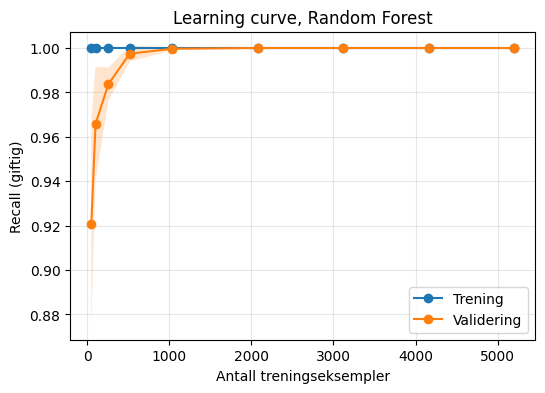

In [11]:
sizes, tr_s, va_s = learning_curve(
    make_rf(**BEST), Xtr, ytr,
    scoring="recall", shuffle=True, random_state=SEED,
    train_sizes=[0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=-1)

plt.figure(figsize=(6, 4))
for s, lab in [(tr_s, "Trening"), (va_s, "Validering")]:
    plt.plot(sizes, s.mean(1), marker="o", label=lab)
    plt.fill_between(sizes, s.mean(1) - s.std(1), s.mean(1) + s.std(1), alpha=0.2)
plt.xlabel("Antall treningseksempler")
plt.ylabel("Recall (giftig)")
plt.title("Learning curve, Random Forest")
plt.legend()
plt.grid(alpha=.3)
plt.savefig("report/figures/B_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

# Feature-subset-eksperimentet
Definer søket:

In [13]:
def fs_model(cols_):
    return make_pipeline(DecisionTreeClassifier(max_depth=6, random_state=SEED), cols_)

def forward_selection(X, y, max_k=10):
    selected, remaining, curve = [], list(X.columns), []
    while remaining and len(selected) < max_k:
        best_f, best_key, best_df = None, None, None
        for f in remaining:
            c = selected + [f]
            df = cv_evaluate(lambda: fs_model(c), X[c], y, n_splits=5)
            key = (df["recall"].mean(), df["accuracy"].mean())
            if best_key is None or key > best_key:
                best_f, best_key, best_df = f, key, df
        selected.append(best_f)
        remaining.remove(best_f)
        curve.append({
            "k": len(selected), "lagt til": best_f,
            "recall": best_df["recall"].mean(), "recall_std": best_df["recall"].std(),
            "accuracy": best_df["accuracy"].mean(), "fn": best_df["fn"].mean(),
        })
        print(len(selected), best_f, round(best_key[0], 4))
    return selected, pd.DataFrame(curve)

print("Funksjoner definert")

Funksjoner definert


Kjør søket:

In [14]:
selected, curve = forward_selection(Xtr, ytr, max_k=10)
curve.to_csv("report/tables/B_feature_subset.csv", index=False)
curve

1 ring-number 0.9805
2 gill-attachment 0.9805
3 veil-color 0.9805
4 odor 0.9706
5 population 0.9917
6 stalk-surface-above-ring 1.0
7 bruises 1.0
8 gill-spacing 1.0
9 spore-print-color 1.0
10 cap-color 1.0


,k,lagt til,recall,recall_std,accuracy,fn
0,1,ring-number,0.980535,0.008757,0.538237,12.2
1,2,gill-attachment,0.980535,0.008757,0.561164,12.2
2,3,veil-color,0.980535,0.008757,0.561164,12.2
3,4,odor,0.970639,0.007604,0.985845,18.4
4,5,population,0.991699,0.003645,0.993845,5.2
5,6,stalk-surface-above-ring,1.000000,0.000000,0.997846,0.0
6,7,bruises,1.000000,0.000000,0.997846,0.0
7,8,gill-spacing,1.000000,0.000000,0.997846,0.0
8,9,spore-print-color,1.000000,0.000000,1.000000,0.0
9,10,cap-color,1.000000,0.000000,1.000000,0.0


Plott kurven:

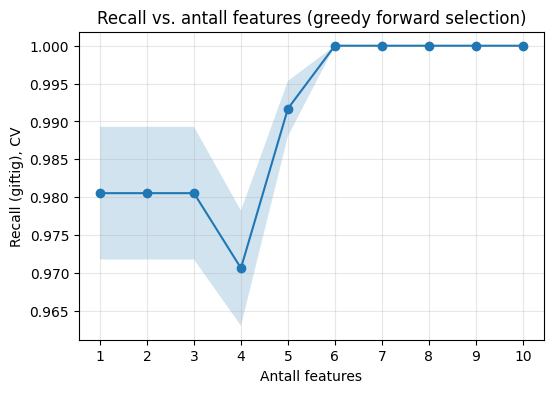

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(curve["k"], curve["recall"], marker="o")
plt.fill_between(curve["k"], curve["recall"] - curve["recall_std"],
                 curve["recall"] + curve["recall_std"], alpha=0.2)
plt.xlabel("Antall features")
plt.ylabel("Recall (giftig), CV")
plt.title("Recall vs. antall features (greedy forward selection)")
plt.xticks(curve["k"])
plt.grid(alpha=.3)
plt.savefig("report/figures/B_feature_subset.png", dpi=200, bbox_inches="tight")
plt.show()

Test delsettene på testsettet:

In [16]:
rows = []
for k in [1, 2, 3, 5, 8, 10]:
    c = selected[:k]
    m = make_pipeline(
        RandomForestClassifier(random_state=SEED, n_jobs=-1, **BEST), c
    ).fit(Xtr[c], ytr)
    rows.append(report(f"Top {k}: {', '.join(c[:3])}{'...' if k > 3 else ''}", yte, m.predict(Xte[c])))

# Til sammenligning: alle 21 features
m_all = make_rf(**BEST).fit(Xtr, ytr)
rows.append(report("Alle 21 features", yte, m_all.predict(Xte)))

subset_test = pd.DataFrame(rows)
subset_test.to_csv("report/tables/B_feature_subset_test.csv", index=False)
subset_test

,Modell,Recall (giftig),Precision (giftig),Accuracy,False negatives,False positives
0,Top 1: ring-number,0.986,0.511,0.538,11,740
1,"Top 2: ring-number, gill-attachment",0.986,0.526,0.564,11,697
2,"Top 3: ring-number, gill-attachment, veil-color",0.986,0.526,0.564,11,697
3,"Top 5: ring-number, gill-attachment, veil-colo...",0.992,0.997,0.995,6,2
4,"Top 8: ring-number, gill-attachment, veil-colo...",1.000,0.997,0.999,0,2
5,"Top 10: ring-number, gill-attachment, veil-col...",1.000,1.000,1.000,0,0
6,Alle 21 features,1.000,1.000,1.000,0,0


Ny forward selection med F2:

In [18]:
from sklearn.metrics import fbeta_score

def cv_f2(make_model, X, y, n_splits=5, seed=SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    out = []
    for tr, va in skf.split(X, y):
        pred = make_model().fit(X.iloc[tr], y.iloc[tr]).predict(X.iloc[va])
        out.append({
            "f2": fbeta_score(y.iloc[va], pred, beta=2),
            "recall": recall_score(y.iloc[va], pred),
            "precision": precision_score(y.iloc[va], pred, zero_division=0),
            "accuracy": accuracy_score(y.iloc[va], pred),
            "fn": ((pred == 0) & (y.iloc[va].to_numpy() == 1)).sum(),
        })
    return pd.DataFrame(out)

def forward_selection_f2(X, y, max_k=10):
    selected, remaining, curve = [], list(X.columns), []
    while remaining and len(selected) < max_k:
        best_f, best_df = None, None
        for f in remaining:
            c = selected + [f]
            df = cv_f2(lambda: fs_model(c), X[c], y)
            if best_df is None or df["f2"].mean() > best_df["f2"].mean():
                best_f, best_df = f, df
        selected.append(best_f); remaining.remove(best_f)
        curve.append({"k": len(selected), "lagt til": best_f,
                      "f2": best_df["f2"].mean(), "recall": best_df["recall"].mean(),
                      "recall_std": best_df["recall"].std(),
                      "precision": best_df["precision"].mean(),
                      "accuracy": best_df["accuracy"].mean(), "fn": best_df["fn"].mean()})
        print(len(selected), best_f, round(best_df["f2"].mean(), 4))
    return selected, pd.DataFrame(curve)

selected_f2, curve_f2 = forward_selection_f2(Xtr, ytr, max_k=10)
curve_f2.to_csv("report/tables/B_feature_subset_f2.csv", index=False)
curve_f2

1 odor 0.9751
2 spore-print-color 0.9908
3 stalk-surface-below-ring 0.998
4 cap-surface 0.9992
5 gill-size 0.9995
6 cap-shape 0.9995
7 cap-color 0.9995
8 bruises 0.9995
9 gill-attachment 0.9995
10 gill-spacing 0.9995


,k,lagt til,f2,recall,recall_std,precision,accuracy,fn
0,1,odor,0.975073,0.969043,0.007517,1.000000,0.985075,19.4
1,2,spore-print-color,0.990785,0.988509,0.002372,1.000000,0.994461,7.2
2,3,stalk-surface-below-ring,0.997957,0.998405,0.002762,0.996185,0.997384,1.0
3,4,cap-surface,0.999171,0.999362,0.001427,0.998409,0.998923,0.4
4,5,gill-size,0.999489,0.999362,0.001427,1.000000,0.999692,0.4
5,6,cap-shape,0.999489,0.999362,0.001427,1.000000,0.999692,0.4
6,7,cap-color,0.999489,0.999362,0.001427,1.000000,0.999692,0.4
7,8,bruises,0.999489,0.999362,0.001427,1.000000,0.999692,0.4
8,9,gill-attachment,0.999489,0.999362,0.001427,1.000000,0.999692,0.4
9,10,gill-spacing,0.999489,0.999362,0.001427,1.000000,0.999692,0.4


Plott og test på testsettet:

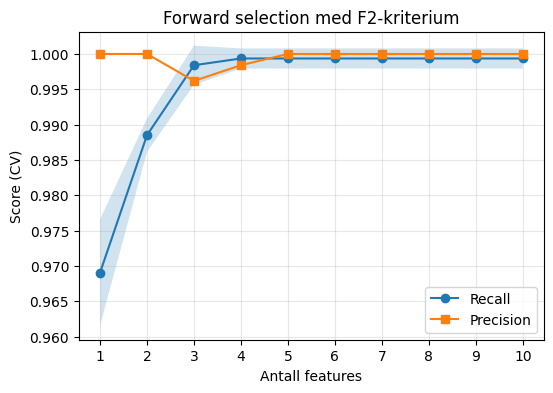

,Modell,Recall (giftig),Precision (giftig),Accuracy,False negatives,False positives
0,Top 1: odor,0.971,1.000,0.986,23,0
1,"Top 2: odor, spore-print-color",0.985,1.000,0.993,12,0
2,"Top 3: odor, spore-print-color, stalk-surface-...",0.996,0.995,0.996,3,4
3,"Top 4: odor, spore-print-color, stalk-surface-...",0.997,0.996,0.997,2,3
4,"Top 5: odor, spore-print-color, stalk-surface-...",0.997,1.000,0.999,2,0
5,"Top 8: odor, spore-print-color, stalk-surface-...",1.000,1.000,1.000,0,0
6,Alle 21 features,1.000,1.000,1.000,0,0


In [19]:
plt.figure(figsize=(6, 4))
plt.plot(curve_f2["k"], curve_f2["recall"], marker="o", label="Recall")
plt.plot(curve_f2["k"], curve_f2["precision"], marker="s", label="Precision")
plt.fill_between(curve_f2["k"], curve_f2["recall"] - curve_f2["recall_std"],
                 curve_f2["recall"] + curve_f2["recall_std"], alpha=0.2)
plt.xlabel("Antall features"); plt.ylabel("Score (CV)")
plt.title("Forward selection med F2-kriterium")
plt.xticks(curve_f2["k"]); plt.legend(); plt.grid(alpha=.3)
plt.savefig("report/figures/B_feature_subset_f2.png", dpi=200, bbox_inches="tight")
plt.show()

rows = []
for k in [1, 2, 3, 4, 5, 8]:
    c = selected_f2[:k]
    m = make_pipeline(RandomForestClassifier(random_state=SEED, n_jobs=-1, **BEST), c).fit(Xtr[c], ytr)
    rows.append(report(f"Top {k}: {', '.join(c)}", yte, m.predict(Xte[c])))
rows.append(report("Alle 21 features", yte, make_rf(**BEST).fit(Xtr, ytr).predict(Xte)))
subset_test_f2 = pd.DataFrame(rows)
subset_test_f2.to_csv("report/tables/B_feature_subset_test_f2.csv", index=False)
subset_test_f2

# "Vet ikke" og feil svar
Uten maskering (trent på vanlig data) og med maskering (trent på data der tilfeldige verdier er byttet ut med "unknown".

Del data og tren de to modellene:

In [21]:
Xfit, Xval, yfit, yval = train_test_split(
    Xtr, ytr, test_size=0.25, stratify=ytr, random_state=SEED)

clean = make_rf(**BEST).fit(Xfit, yfit)          # uten maskering
Xa_fit, ya_fit = augment(Xfit, yfit)
robust = make_rf(**BEST).fit(Xa_fit, ya_fit)     # med maskering

print("Trening:", Xfit.shape, " Validering:", Xval.shape)
print("Maskert treningssett:", Xa_fit.shape)

Trening: (4874, 21)  Validering: (1625, 21)
Maskert treningssett: (14622, 21)


"Vet ikke"-test:

In [22]:
def eval_noisy(model, X, y, p, fn_noise, n_seeds=10):
    out = []
    for s in range(n_seeds):
        Xn = X if p == 0 else fn_noise(X, p, 1000 + s)
        out.append(report("", y, model.predict(Xn)))
    d = pd.DataFrame(out)
    return (d["Recall (giftig)"].mean(), d["Accuracy"].mean(),
            d["False negatives"].mean())

rows = []
for p in [0, 0.1, 0.2, 0.4, 0.6]:
    for name, m in [("Uten maskering i trening", clean), ("Med maskering i trening", robust)]:
        r, a, fn = eval_noisy(m, Xval, yval, p, mask_unknown)
        rows.append({"Andel 'unknown'": f"{int(p*100)} %", "Modell": name,
                     "Recall (giftig)": round(r, 3), "Accuracy": round(a, 3),
                     "FN (snitt)": round(fn, 1)})
tab_unknown = pd.DataFrame(rows)
tab_unknown.to_csv("report/tables/B_robusthet_unknown.csv", index=False)
tab_unknown

,Andel 'unknown',Modell,Recall (giftig),Accuracy,FN (snitt)
0,0 %,Uten maskering i trening,1.000,1.000,0.0
1,0 %,Med maskering i trening,1.000,1.000,0.0
2,10 %,Uten maskering i trening,0.996,0.998,3.0
3,10 %,Med maskering i trening,1.000,1.000,0.4
4,20 %,Uten maskering i trening,0.985,0.992,12.1
5,20 %,Med maskering i trening,0.998,0.999,1.4
6,40 %,Uten maskering i trening,0.915,0.955,66.9
7,40 %,Med maskering i trening,0.972,0.984,21.7
8,60 %,Uten maskering i trening,0.755,0.874,191.6
9,60 %,Med maskering i trening,0.910,0.946,70.3


Feil-svar-test:

In [23]:
rows = []
for p in [0, 0.05, 0.1, 0.2]:
    for name, m in [("Uten maskering i trening", clean), ("Med maskering i trening", robust)]:
        r, a, fn = eval_noisy(m, Xval, yval, p, corrupt)
        rows.append({"Andel feil verdier": f"{int(p*100)} %", "Modell": name,
                     "Recall (giftig)": round(r, 3), "Accuracy": round(a, 3),
                     "FN (snitt)": round(fn, 1)})
tab_wrong = pd.DataFrame(rows)
tab_wrong.to_csv("report/tables/B_robusthet_feil.csv", index=False)
tab_wrong

,Andel feil verdier,Modell,Recall (giftig),Accuracy,FN (snitt)
0,0 %,Uten maskering i trening,1.000,1.000,0.0
1,0 %,Med maskering i trening,1.000,1.000,0.0
2,5 %,Uten maskering i trening,0.997,0.997,2.3
3,5 %,Med maskering i trening,0.999,0.998,0.8
4,10 %,Uten maskering i trening,0.991,0.991,6.8
5,10 %,Med maskering i trening,0.996,0.994,2.8
6,20 %,Uten maskering i trening,0.975,0.976,20.1
7,20 %,Med maskering i trening,0.983,0.977,13.1


# Terskler og "usikker"-sone
Beregn sannsynlighetene:

In [25]:
p_oof, y_oof = oof_proba(lambda: make_rf(**BEST), Xtr, ytr,
                         val_mask_ps=(0, 0.2, 0.4), augment_train=True)
print(p_oof.shape, " andel giftige:", y_oof.mean().round(3))

(19497,)  andel giftige: 0.482


Terskeltabell og valg av T_LOW / T_HIGH:

In [26]:
rows = []
for t in [0.01, 0.05, 0.1, 0.3, 0.5, 0.9, 0.95]:
    rows.append(report(f"t={t}", y_oof, (p_oof >= t).astype(int)))
tab_thr = pd.DataFrame(rows)
tab_thr.to_csv("report/tables/B_terskler.csv", index=False)
display(tab_thr)

T_LOW, T_HIGH = choose_thresholds(y_oof, p_oof)
print("T_LOW =", T_LOW, " T_HIGH =", T_HIGH)
cfg = {"T_LOW": T_LOW, "T_HIGH": T_HIGH}
json.dump(cfg, open("models/config.json", "w"), indent=2)

# Hvordan fordeles radene på de tre sonene?
zone = np.where(p_oof <= T_LOW, "ingen tegn på gift",
       np.where(p_oof >= T_HIGH, "sannsynlig giftig", "usikker"))
print(pd.crosstab(pd.Series(y_oof).map({0: "spiselig", 1: "giftig"}), zone))

,Modell,Recall (giftig),Precision (giftig),Accuracy,False negatives,False positives
0,t=0.01,1.000,0.732,0.824,0,3434
1,t=0.05,1.000,0.856,0.919,0,1585
2,t=0.1,1.000,0.914,0.954,2,887
3,t=0.3,0.999,0.986,0.993,14,131
4,t=0.5,0.993,0.998,0.995,68,20
5,t=0.9,0.920,1.000,0.962,748,0
6,t=0.95,0.866,1.000,0.935,1262,0


T_LOW = 0.025  T_HIGH = 0.5
col_0     ingen tegn på gift  sannsynlig giftig  usikker
row_0                                                   
giftig                     0               9331       68
spiselig                7889                 20     2189


# Endelig modell, testsett, feilanalyse og importance
Tren endelig modell og evaluer på testsettet:

{'Modell': 'Final RF (maskert trening)', 'Recall (giftig)': 1.0, 'Precision (giftig)': 1.0, 'Accuracy': 1.0, 'False negatives': np.int64(0), 'False positives': np.int64(0)}


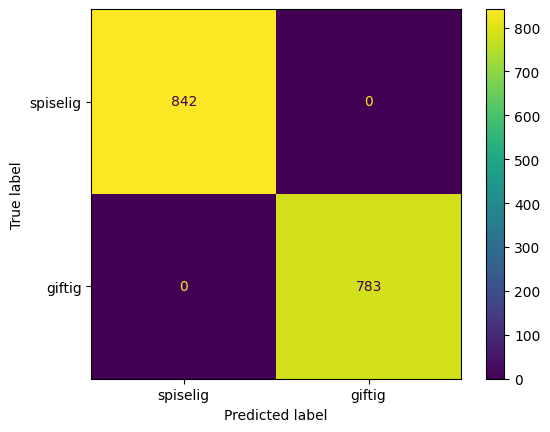


--- 0 % 'unknown' ---
col_0      ingen tegn på gift  sannsynlig giftig
poisonous                                       
giftig                      0                783
spiselig                  842                  0

--- 20 % 'unknown' ---
col_0      ingen tegn på gift  sannsynlig giftig  usikker
poisonous                                                
giftig                      0                781        2
spiselig                  698                  1      143

--- 40 % 'unknown' ---
col_0      ingen tegn på gift  sannsynlig giftig  usikker
poisonous                                                
giftig                      0                755       28
spiselig                  478                  7      357


In [28]:
cfg = json.load(open("models/config.json"))
Xa, ya = augment(Xtr, ytr)
final = make_rf(**BEST).fit(Xa, ya)
joblib.dump(final, "models/model.joblib")

pred = final.predict(Xte)
print(report("Final RF (maskert trening)", yte, pred))
ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=["spiselig", "giftig"])
plt.savefig("report/figures/B_confusion_test.png", dpi=200, bbox_inches="tight")
plt.show()

def zones(p):
    return np.where(p <= cfg["T_LOW"], "ingen tegn på gift",
           np.where(p >= cfg["T_HIGH"], "sannsynlig giftig", "usikker"))

for q in [0, 0.2, 0.4]:
    Xq = Xte if q == 0 else mask_unknown(Xte, q, 7)
    p = final.predict_proba(Xq)[:, 1]
    print(f"\n--- {int(q*100)} % 'unknown' ---")
    print(pd.crosstab(yte.map({0: "spiselig", 1: "giftig"}), zones(p)))

Feilanalyse:

In [30]:
def show_errors(Xq, name):
    pr = final.predict(Xq)
    mask_ = pr != yte.values
    wrong = Xq[mask_].copy()
    wrong["fasit"] = yte[mask_].map({0: "spiselig", 1: "giftig"})
    wrong["p_giftig"] = final.predict_proba(Xq[mask_])[:, 1].round(3) if mask_.any() else []
    print(f"{name}: {mask_.sum()} feil")
    return wrong

e_clean = show_errors(Xte, "Rene testdata")
Xm = mask_unknown(Xte, 0.4, 7)
e_mask = show_errors(Xm, "40 % maskert")
e_mask[e_mask["fasit"] == "giftig"].head(10)

Rene testdata: 0 feil
40 % maskert: 35 feil


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat,fasit,p_giftig
42,unknown,unknown,unknown,unknown,unknown,unknown,c,unknown,unknown,e,...,p,n,w,o,unknown,unknown,y,g,giftig,0.46
45,unknown,s,p,t,n,f,unknown,b,unknown,e,...,w,unknown,w,t,unknown,unknown,unknown,m,giftig,0.28
121,x,s,unknown,unknown,unknown,f,unknown,unknown,unknown,t,...,w,w,w,unknown,p,unknown,v,unknown,giftig,0.42
128,unknown,f,unknown,unknown,unknown,unknown,unknown,n,unknown,unknown,...,w,w,w,o,unknown,unknown,v,unknown,giftig,0.46
208,x,f,unknown,unknown,unknown,f,c,unknown,u,unknown,...,unknown,w,w,o,p,unknown,unknown,unknown,giftig,0.18
216,b,unknown,unknown,unknown,n,f,w,n,unknown,e,...,w,unknown,w,o,p,unknown,c,l,giftig,0.46
221,unknown,y,w,unknown,unknown,unknown,unknown,unknown,unknown,unknown,...,unknown,w,w,o,p,unknown,unknown,g,giftig,0.22
225,x,f,unknown,unknown,unknown,unknown,unknown,unknown,h,unknown,...,b,unknown,unknown,o,unknown,unknown,y,unknown,giftig,0.50
267,unknown,f,w,f,unknown,unknown,w,n,n,unknown,...,w,unknown,unknown,o,p,unknown,unknown,d,giftig,0.44
290,unknown,s,p,unknown,unknown,f,unknown,unknown,u,unknown,...,w,unknown,w,unknown,unknown,n,unknown,d,giftig,0.38


Feature importance:

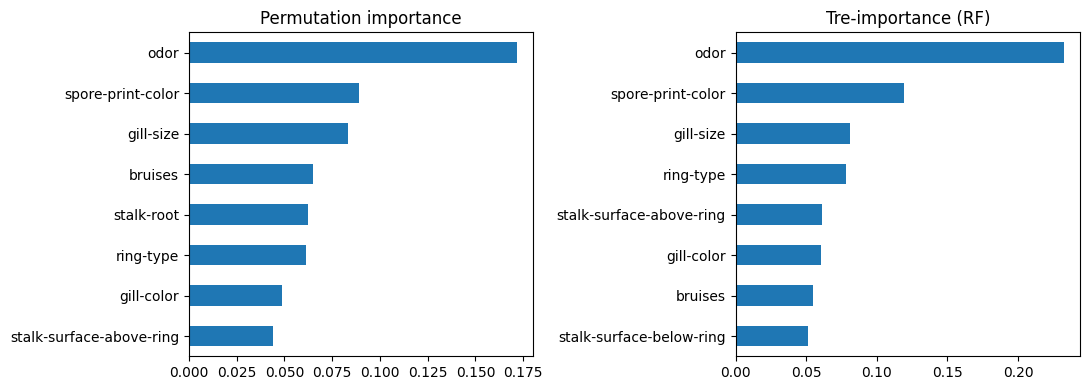

odor                        0.171752
spore-print-color           0.088944
gill-size                   0.083273
bruises                     0.065043
stalk-root                  0.062304
ring-type                   0.061523
gill-color                  0.048573
stalk-surface-above-ring    0.044160
dtype: float64
odor                        0.232311
spore-print-color           0.118965
gill-size                   0.080917
ring-type                   0.078290
stalk-surface-above-ring    0.061318
gill-color                  0.060583
bruises                     0.054858
stalk-surface-below-ring    0.051271
dtype: float64


In [31]:
perm = permutation_importance(final, Xte, yte, scoring="neg_log_loss",
                              n_repeats=10, random_state=SEED, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=cols).sort_values(ascending=False)

ohe_names = final.named_steps["pre"].get_feature_names_out()
tree_imp = pd.Series(final.named_steps["model"].feature_importances_, index=ohe_names)
imp_tree = (tree_imp.groupby(lambda n: n.replace("cat__", "").rsplit("_", 1)[0]).sum()
            .sort_values(ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
imp_perm.head(8)[::-1].plot.barh(ax=ax[0], title="Permutation importance")
imp_tree.head(8)[::-1].plot.barh(ax=ax[1], title="Tre-importance (RF)")
plt.tight_layout()
plt.savefig("report/figures/B_importance.png", dpi=200, bbox_inches="tight")
plt.show()
print(imp_perm.head(8)); print(imp_tree.head(8))